# BeExpand - Modelo de Forecasting
## Cash Flow Forecasting con Prophet

**Pipeline:** Carga -> Exploracion -> Train/Test Split -> Prophet -> Evaluacion -> Prediccion 30/60/90 -> Visualizacion -> Exportacion

---

## 1. Importaciones y Configuracion

In [1]:
# ============================================================
# 1. IMPORTACIONES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import pickle
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Importaciones cargadas correctamente.')
print(f'Prophet version: {Prophet.__module__}')

Importing plotly failed. Interactive plots will not work.


Importaciones cargadas correctamente.
Prophet version: prophet.forecaster


In [2]:
# ============================================================
# 1b. CONFIGURACION DE RUTAS
# ============================================================
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = os.path.join(PROCESSED_DIR, 'be_expand_consolidado.csv')

print(f'Datos: {DATA_PATH}')
print(f'Modelos: {MODEL_DIR}')

Datos: ..\data\processed\be_expand_consolidado.csv
Modelos: ..\models


---
## 2. Carga y Exploracion de Datos

In [3]:
# ============================================================
# 2a. CARGAR DATOS CONSOLIDADOS
# ============================================================
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# Convertir anio_mes a datetime (primer dia del mes)
df['ds'] = pd.to_datetime(df['anio_mes'].astype(str) + '-01')

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Rango de fechas: {df["ds"].min().date()} a {df["ds"].max().date()}')
print(f'Periodo: {df["ds"].min().date()} - {df["ds"].max().date()} ({(df["ds"].max() - df["ds"].min()).days // 30} meses)')
print()
df.head(10)

Dataset cargado: 40 filas x 20 columnas
Rango de fechas: 2023-01-01 a 2026-04-01
Periodo: 2023-01-01 - 2026-04-01 (39 meses)



,anio_mes,proyecto,recurrente,total_ingresos,Estructura,Marketing,Operaciones,Personal,Tecnologia,Tributario,Viajes y Ferias,total_gastos,saldo_cierre_mes,ipc_interanual_pct,euribor_12m_pct,factor_estacional,cash_flow_neto,ratio_cobertura,variacion_saldo,ds
0,2023-01,0.0,65485.2,65485.2,15500.1,0.0,0.0,172740.0,5892.7,0.0,0.0,194132.8,329978.38,5.8,3.35,1.10,-128647.6,33.7,0.0,2023-01-01
1,2023-02,0.0,64033.2,64033.2,19650.4,0.0,0.0,191260.0,5154.6,0.0,0.0,216065.0,189659.38,6.0,3.55,0.95,-152031.8,29.6,-140319.0,2023-02-01
2,2023-03,49779.4,84119.2,133898.6,14858.8,0.0,0.0,183900.0,6703.4,0.0,22167.2,227629.4,59797.98,5.5,3.70,1.15,-93730.8,58.8,-129861.4,2023-03-01
3,2023-04,13769.8,120721.7,134491.5,13939.2,14157.0,0.0,188840.0,7175.3,48520.0,0.0,272631.5,-93440.22,4.8,3.85,1.20,-138140.0,49.3,-153238.2,2023-04-01
4,2023-05,38635.3,136185.5,174820.8,17738.6,0.0,0.0,179300.0,6134.7,0.0,0.0,203173.3,13970.98,4.2,3.90,1.05,-28352.5,86.0,107411.2,2023-05-01
5,2023-06,3642.1,154517.0,158159.1,14544.2,0.0,0.0,191700.0,7139.0,0.0,7477.8,220861.0,-54018.62,3.8,4.00,1.00,-62701.9,71.6,-67989.6,2023-06-01
6,2023-07,9655.8,139065.3,148721.1,15306.5,0.0,0.0,191610.0,7175.3,40420.0,0.0,254511.8,122232.38,3.5,4.05,0.90,-105790.7,58.4,176251.0,2023-07-01
7,2023-08,12233.1,92710.2,104943.3,16710.1,0.0,0.0,172930.0,6328.3,0.0,4101.9,200070.3,39005.78,3.6,4.10,0.50,-95127.0,52.5,-83226.6,2023-08-01
8,2023-09,16661.7,183012.5,199674.2,15367.0,689.7,0.0,186420.0,5578.1,0.0,0.0,208054.8,-66211.12,3.8,4.15,1.15,-8380.6,96.0,-105216.9,2023-09-01
9,2023-10,49343.8,196988.0,246331.8,15246.0,0.0,0.0,192060.0,5445.0,60200.0,21671.1,294622.1,22983.48,3.5,4.05,1.20,-48290.3,83.6,89194.6,2023-10-01


In [4]:
# ============================================================
# 2b. ESTADISTICAS DESCRIPTIVAS
# ============================================================
print('=== ESTADISTICAS DE LAS VARIABLES PRINCIPALES ===')
print()
metricas = ['total_ingresos', 'total_gastos', 'cash_flow_neto', 'saldo_cierre_mes',
            'recurrente', 'proyecto', 'ratio_cobertura']
print(df[metricas].describe().round(2).to_string())
print()
print('=== VARIABLES EXTERNAS ===')
print(df[['ipc_interanual_pct', 'euribor_12m_pct', 'factor_estacional']].describe().round(3).to_string())

=== ESTADISTICAS DE LAS VARIABLES PRINCIPALES ===

       total_ingresos  total_gastos  cash_flow_neto  saldo_cierre_mes  recurrente  proyecto  ratio_cobertura
count           40.00         40.00           40.00             40.00       40.00     40.00            40.00
mean        273528.06     224685.12        48842.94         707323.34   247621.36  25906.70           122.87
std         104701.55      29005.71       104960.03         876860.52    95671.24  19457.20            49.01
min          64033.20     194132.80      -152031.80         -93440.22    64033.20      0.00            29.60
25%         195793.12     204250.45       -13373.58          18631.48   182489.18  12859.28            93.50
50%         276019.15     214087.45        41228.15         233073.78   249253.95  23939.85           119.05
75%         368777.75     233515.62       136066.45        1473297.20   343664.20  38444.72           165.18
max         432756.50     294622.10       234058.20        2600096.78   36788

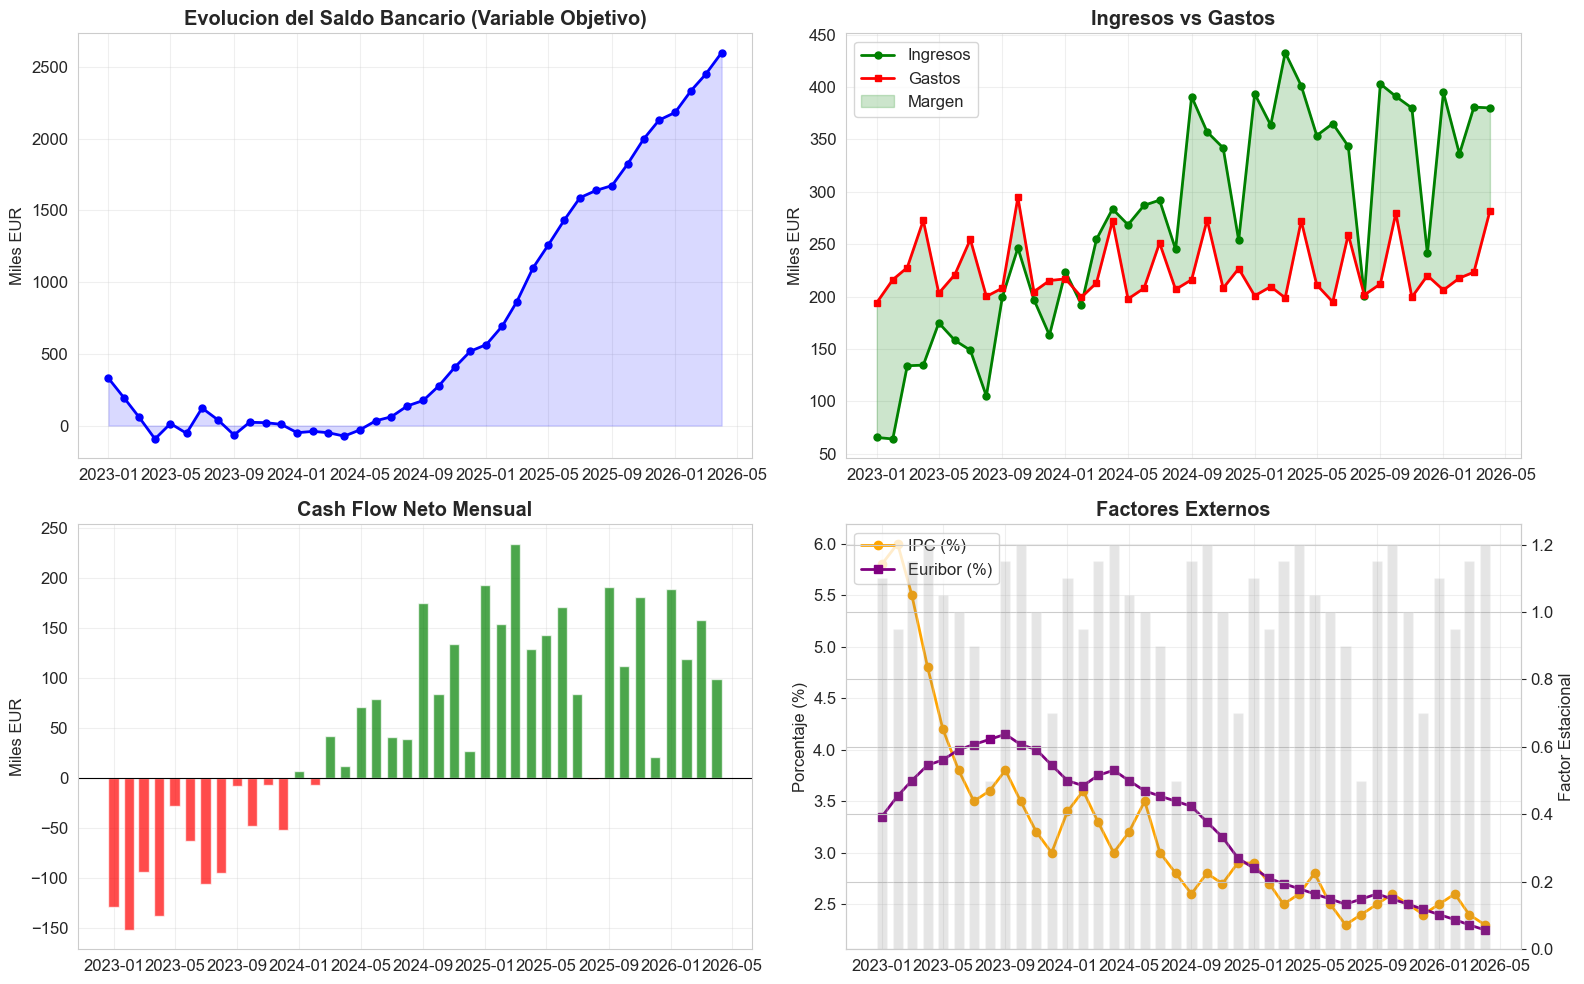

Graficos generados. Se observa tendencia alcista en saldo y estacionalidad clara.


In [5]:
# ============================================================
# 2c. VISUALIZACION DE LA SERIE TEMPORAL
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

x = df['ds']

# G1: Saldo Bancario (target principal)
ax = axes[0, 0]
ax.plot(x, df['saldo_cierre_mes']/1000, 'b-o', linewidth=2, markersize=5)
ax.fill_between(x, 0, df['saldo_cierre_mes']/1000, alpha=0.15, color='blue')
ax.set_title('Evolucion del Saldo Bancario (Variable Objetivo)', fontweight='bold')
ax.set_ylabel('Miles EUR')
ax.grid(True, alpha=0.3)

# G2: Ingresos vs Gastos
ax = axes[0, 1]
ax.plot(x, df['total_ingresos']/1000, 'g-o', linewidth=2, markersize=5, label='Ingresos')
ax.plot(x, df['total_gastos']/1000, 'r-s', linewidth=2, markersize=5, label='Gastos')
ax.fill_between(x, df['total_gastos']/1000, df['total_ingresos']/1000,
                alpha=0.2, color='green', label='Margen')
ax.set_title('Ingresos vs Gastos', fontweight='bold')
ax.set_ylabel('Miles EUR')
ax.legend()
ax.grid(True, alpha=0.3)

# G3: Cash Flow Neto
ax = axes[1, 0]
colores = ['green' if v >= 0 else 'red' for v in df['cash_flow_neto']]
ax.bar(x, df['cash_flow_neto']/1000, color=colores, alpha=0.7, width=20)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Cash Flow Neto Mensual', fontweight='bold')
ax.set_ylabel('Miles EUR')
ax.grid(True, alpha=0.3)

# G4: Variables Externas
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(x, df['ipc_interanual_pct'], 'orange', linewidth=2, marker='o', label='IPC (%)')
ax.plot(x, df['euribor_12m_pct'], 'purple', linewidth=2, marker='s', label='Euribor (%)')
ax2.bar(x, df['factor_estacional'], alpha=0.2, color='gray', width=20, label='Estacionalidad')
ax.set_title('Factores Externos', fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax2.set_ylabel('Factor Estacional')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Graficos generados. Se observa tendencia alcista en saldo y estacionalidad clara.')

---
## 3. Division Train/Test

Usamos **80/20** dividiendo por tiempo (no aleatorio):
- Train: primeros 32 meses (Ene 2023 - Ago 2025)
- Test: ultimos 8 meses (Sep 2025 - Abr 2026)

Total: 40 meses
Train: 32 meses (2023-01-01 a 2025-08-01)
Test:  8 meses (2025-09-01 a 2026-04-01)
Proporcion: 80/20


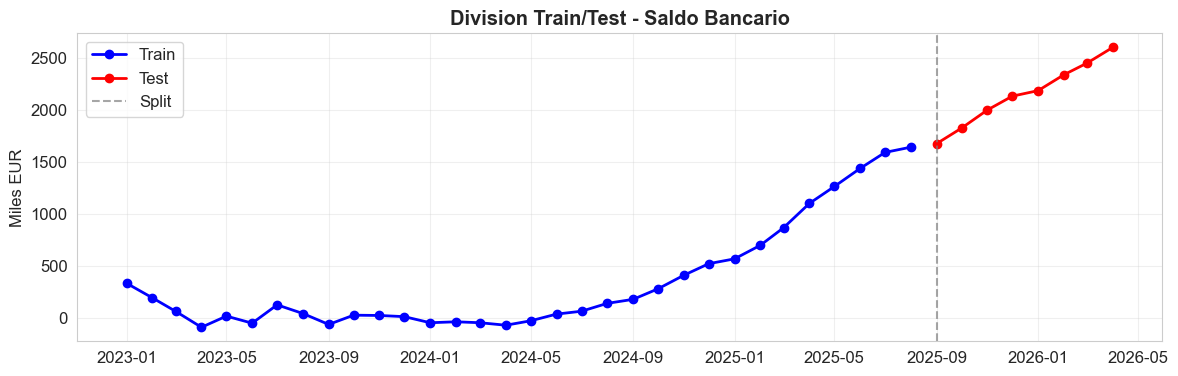

Primer mes test: 2025-09-01 -> se predicen 8 meses


In [6]:
# ============================================================
# 3. DIVISION TRAIN/TEST (80/20 temporal)
# ============================================================
split_idx = int(len(df) * 0.8)

df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()

print(f'Total: {len(df)} meses')
print(f'Train: {len(df_train)} meses ({df_train["ds"].min().date()} a {df_train["ds"].max().date()})')
print(f'Test:  {len(df_test)} meses ({df_test["ds"].min().date()} a {df_test["ds"].max().date()})')
print(f'Proporcion: {len(df_train)/len(df)*100:.0f}/{len(df_test)/len(df)*100:.0f}')

# Visualizar split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train['ds'], df_train['saldo_cierre_mes']/1000, 'b-o', linewidth=2, label='Train')
ax.plot(df_test['ds'], df_test['saldo_cierre_mes']/1000, 'r-o', linewidth=2, label='Test')
ax.axvline(x=df_test['ds'].iloc[0], color='gray', linestyle='--', alpha=0.7, label='Split')
ax.set_title('Division Train/Test - Saldo Bancario', fontweight='bold')
ax.set_ylabel('Miles EUR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()
print(f'Primer mes test: {df_test["ds"].iloc[0].date()} -> se predicen {len(df_test)} meses')

---
## 4. Modelo Prophet Base

Entrenamos Prophet con:
- **Target (y)**: `saldo_cierre_mes` (posicion de tesoreria)
- **Regresores externos**: IPC, Euribor, factor estacional
- **Estacionalidad anual**: activada por defecto (datos mensuales)
- **Estacionalidad mensual**: desactivada (no tiene sentido con datos mensuales)

In [7]:
# ============================================================
# 4a. PREPARAR DATOS PARA PROPHET
# ============================================================
# Prophet requiere columnas: ds (fecha), y (target)
df_prophet_train = pd.DataFrame({
    'ds': df_train['ds'],
    'y': df_train['saldo_cierre_mes'],
    'ipc': df_train['ipc_interanual_pct'],
    'euribor': df_train['euribor_12m_pct'],
    'estacionalidad': df_train['factor_estacional'],
    'ingresos': df_train['total_ingresos'],
    'gastos': df_train['total_gastos'],
})

df_prophet_test = pd.DataFrame({
    'ds': df_test['ds'],
    'y': df_test['saldo_cierre_mes'],
    'ipc': df_test['ipc_interanual_pct'],
    'euribor': df_test['euribor_12m_pct'],
    'estacionalidad': df_test['factor_estacional'],
    'ingresos': df_test['total_ingresos'],
    'gastos': df_test['total_gastos'],
})

print('Train DataFrame para Prophet:')
print(df_prophet_train.head(3).to_string())
print(f'\nDimensiones train: {df_prophet_train.shape}')
print(f'Dimensiones test: {df_prophet_test.shape}')

Train DataFrame para Prophet:
          ds          y  ipc  euribor  estacionalidad  ingresos    gastos
0 2023-01-01  329978.38  5.8     3.35            1.10   65485.2  194132.8
1 2023-02-01  189659.38  6.0     3.55            0.95   64033.2  216065.0
2 2023-03-01   59797.98  5.5     3.70            1.15  133898.6  227629.4

Dimensiones train: (32, 7)
Dimensiones test: (8, 7)


In [8]:
# ============================================================
# 4b. ENTRENAR MODELO PROPHET
# ============================================================
print('Entrenando modelo Prophet...')
print('=' * 50)

modelo = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.95
)

# Anadir regresores externos
modelo.add_regressor('ipc')
modelo.add_regressor('euribor')
modelo.add_regressor('estacionalidad')
modelo.add_regressor('ingresos')
modelo.add_regressor('gastos')

# Entrenar
modelo.fit(df_prophet_train)

print('Modelo Prophet entrenado correctamente.')
print(f'\nParametros del modelo:')
print(f'  - Estacionalidad anual: {modelo.yearly_seasonality}')
print(f'  - Modo estacionalidad: {modelo.seasonality_mode}')
print(f'  - Changepoint prior: {modelo.changepoint_prior_scale}')
print(f'  - Seasonality prior: {modelo.seasonality_prior_scale}')
print(f'  - Intervalo de confianza: {modelo.interval_width*100:.0f}%')

10:20:32 - cmdstanpy - INFO - Chain [1] start processing


Entrenando modelo Prophet...


10:20:32 - cmdstanpy - INFO - Chain [1] done processing


Modelo Prophet entrenado correctamente.

Parametros del modelo:
  - Estacionalidad anual: True
  - Modo estacionalidad: multiplicative
  - Changepoint prior: 0.05
  - Seasonality prior: 10.0
  - Intervalo de confianza: 95%


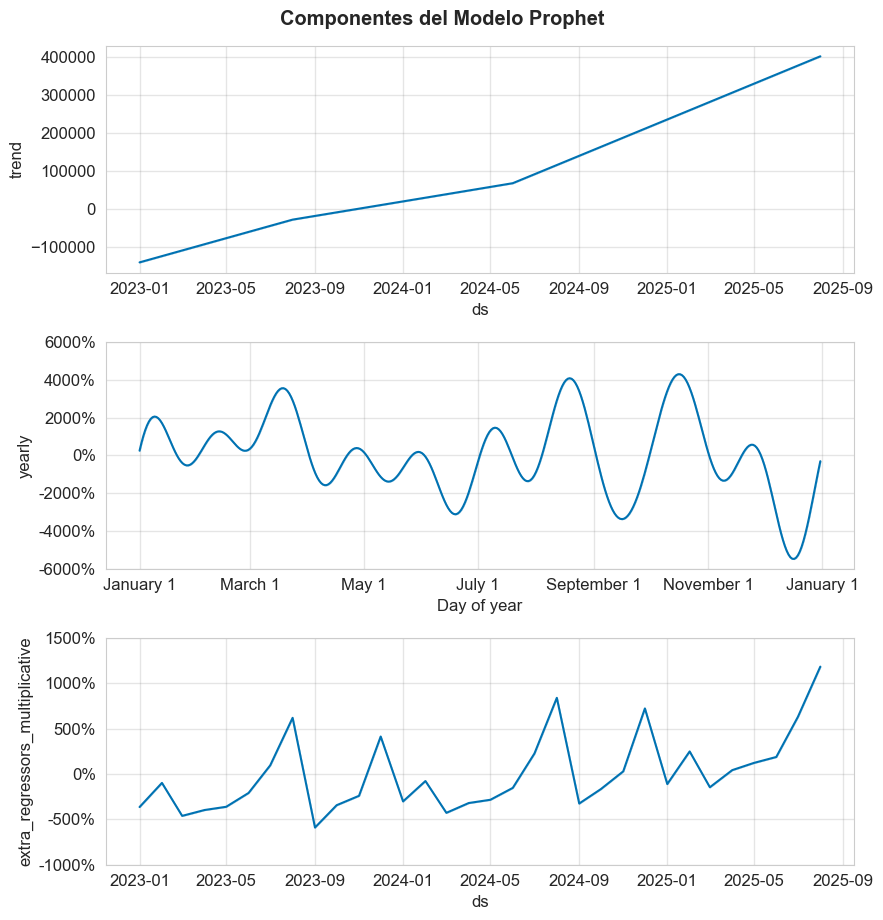

Grafico de componentes generado.


In [9]:
# ============================================================
# 4c. ANALISIS DE COMPONENTES
# ============================================================
# Generar forecast en train para analizar componentes
forecast_train = modelo.predict(df_prophet_train)
fig_comp = modelo.plot_components(forecast_train)
plt.suptitle('Componentes del Modelo Prophet', fontweight='bold', y=1.02)
plt.show()
print('Grafico de componentes generado.')

---
## 5. Evaluacion del Modelo (Periodo Test)

Predecimos los 8 meses del periodo test y comparamos con los valores reales.

In [10]:
# ============================================================
# 5a. PREDECIR PERIODO TEST
# ============================================================
# Crear DataFrame futuro con los regresores del periodo test
df_future_test = df_prophet_test[['ds', 'ipc', 'euribor', 'estacionalidad', 'ingresos', 'gastos']].copy()

# Predecir
forecast_test = modelo.predict(df_future_test)

# Extraer predicciones
df_test['prediccion'] = forecast_test['yhat'].values
df_test['yhat_lower'] = forecast_test['yhat_lower'].values
df_test['yhat_upper'] = forecast_test['yhat_upper'].values

print('=== PREDICCIONES PERIODO TEST ===')
print()
resultados = pd.DataFrame({
    'Mes': df_test['ds'].dt.strftime('%Y-%m'),
    'Real (EUR)': df_test['saldo_cierre_mes'].values,
    'Prediccion (EUR)': df_test['prediccion'].values,
    'Error (EUR)': df_test['prediccion'].values - df_test['saldo_cierre_mes'].values,
    'Error %': ((df_test['prediccion'].values - df_test['saldo_cierre_mes'].values) / df_test['saldo_cierre_mes'].values * 100).round(1),
    'IC Inferior': df_test['yhat_lower'].values,
    'IC Superior': df_test['yhat_upper'].values,
})
print(resultados.to_string(index=False))

=== PREDICCIONES PERIODO TEST ===

    Mes  Real (EUR)  Prediccion (EUR)   Error (EUR)  Error %  IC Inferior  IC Superior
2025-09  1673279.98      2.153569e+06  4.802891e+05     28.7 2.117044e+06 2.188660e+06
2025-10  1822612.58      1.549427e+06 -2.731856e+05    -15.0 1.510269e+06 1.585392e+06
2025-11  1996781.58      2.293443e+06  2.966614e+05     14.9 2.243284e+06 2.340979e+06
2025-12  2129907.88      2.531421e+06  4.015131e+05     18.9 2.465566e+06 2.595422e+06
2026-01  2183051.58      1.708578e+06 -4.744731e+05    -21.7 1.649572e+06 1.769269e+06
2026-02  2335653.98      2.244747e+06 -9.090711e+04     -3.9 2.149957e+06 2.333911e+06
2026-03  2448750.98      3.010004e+06  5.612533e+05     22.9 2.879724e+06 3.143474e+06
2026-04  2600096.78      3.789819e+06  1.189722e+06     45.8 3.596764e+06 3.983432e+06


In [11]:
# ============================================================
# 5b. METRICAS DE ERROR
# ============================================================
y_true = df_test['saldo_cierre_mes'].values
y_pred = df_test['prediccion'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

# R2 Score manual
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print('=== METRICAS DE EVALUACION (PERIODO TEST) ===')
print('=' * 50)
print(f'  MAE:  {mae:>12,.2f} EUR  (Error absoluto medio)')
print(f'  RMSE: {rmse:>12,.2f} EUR  (Raiz error cuadratico medio)')
print(f'  MAPE: {mape:>10.2f} %    (Error porcentual absoluto medio)')
print(f'  R²:   {r2:>10.4f}          (Coeficiente de determinacion)')
print('=' * 50)
print()
if mape < 5:
    print('RESULTADO: EXCELENTE - Error menor del 5%')
elif mape < 10:
    print('RESULTADO: BUENO - Error entre 5% y 10%')
elif mape < 20:
    print('RESULTADO: ACEPTABLE - Error entre 10% y 20%')
else:
    print('RESULTADO: NECESITA MEJORA - Error superior al 20%')

=== METRICAS DE EVALUACION (PERIODO TEST) ===
  MAE:    471,000.57 EUR  (Error absoluto medio)
  RMSE:   561,066.05 EUR  (Raiz error cuadratico medio)
  MAPE:      21.46 %    (Error porcentual absoluto medio)
  R²:      -2.6726          (Coeficiente de determinacion)

RESULTADO: NECESITA MEJORA - Error superior al 20%


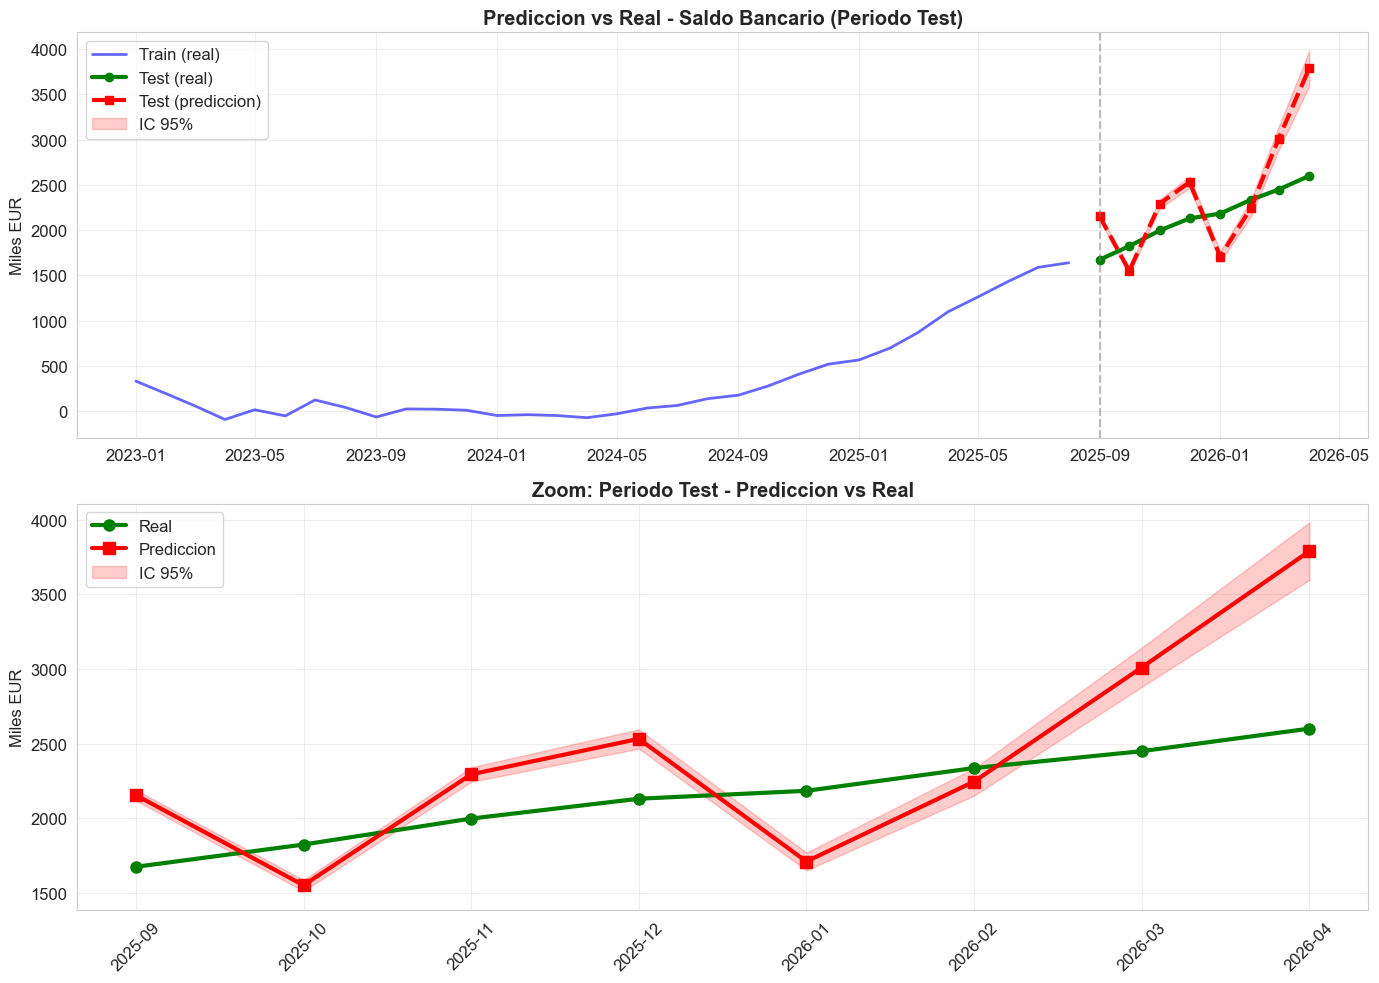

MAE: 471,000.57 EUR | RMSE: 561,066.05 EUR | MAPE: 21.46%


In [12]:
# ============================================================
# 5c. VISUALIZAR PREDICCIONES VS REALES (TEST)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# G1: Serie completa (train + test con prediccion)
ax = axes[0]
# Train
ax.plot(df_train['ds'], df_train['saldo_cierre_mes']/1000,
        'b-', linewidth=2, alpha=0.6, label='Train (real)')
# Test - real
ax.plot(df_test['ds'], df_test['saldo_cierre_mes']/1000,
        'g-', linewidth=3, marker='o', label='Test (real)')
# Test - prediccion
ax.plot(df_test['ds'], df_test['prediccion']/1000,
        'r--', linewidth=3, marker='s', label='Test (prediccion)')
# Intervalo de confianza
ax.fill_between(df_test['ds'],
                df_test['yhat_lower']/1000,
                df_test['yhat_upper']/1000,
                alpha=0.2, color='red', label='IC 95%')
ax.axvline(x=df_test['ds'].iloc[0], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Prediccion vs Real - Saldo Bancario (Periodo Test)', fontweight='bold')
ax.set_ylabel('Miles EUR')
ax.legend()
ax.grid(True, alpha=0.3)

# G2: Zoom solo periodo test
ax = axes[1]
x_test = range(len(df_test))
ax.plot(x_test, df_test['saldo_cierre_mes']/1000,
        'g-o', linewidth=3, markersize=8, label='Real')
ax.plot(x_test, df_test['prediccion']/1000,
        'r-s', linewidth=3, markersize=8, label='Prediccion')
ax.fill_between(x_test,
                df_test['yhat_lower']/1000,
                df_test['yhat_upper']/1000,
                alpha=0.2, color='red', label='IC 95%')
ax.set_xticks(x_test)
ax.set_xticklabels(df_test['ds'].dt.strftime('%Y-%m'), rotation=45)
ax.set_title('Zoom: Periodo Test - Prediccion vs Real', fontweight='bold')
ax.set_ylabel('Miles EUR')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'MAE: {mae:,.2f} EUR | RMSE: {rmse:,.2f} EUR | MAPE: {mape:.2f}%')

---
## 6. Prediccion a 30/60/90 Dias

Una vez validado el modelo, entrenamos con TODOS los datos disponibles y predecimos los proximos 3 meses (Julio, Agosto, Septiembre 2026).

**Nota:** Para los regresores externos (IPC, Euribor, estacionalidad) usamos los valores del mismo mes del ano anterior como aproximacion.

In [13]:
# ============================================================
# 6a. ENTRENAR MODELO FINAL CON TODOS LOS DATOS
# ============================================================
print('Entrenando modelo final con TODOS los datos disponibles...')

df_prophet_full = pd.DataFrame({
    'ds': df['ds'],
    'y': df['saldo_cierre_mes'],
    'ipc': df['ipc_interanual_pct'],
    'euribor': df['euribor_12m_pct'],
    'estacionalidad': df['factor_estacional'],
    'ingresos': df['total_ingresos'],
    'gastos': df['total_gastos'],
})

modelo_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    interval_width=0.95
)

modelo_final.add_regressor('ipc')
modelo_final.add_regressor('euribor')
modelo_final.add_regressor('estacionalidad')
modelo_final.add_regressor('ingresos')
modelo_final.add_regressor('gastos')

modelo_final.fit(df_prophet_full)

print('Modelo final entrenado correctamente.')

10:20:33 - cmdstanpy - INFO - Chain [1] start processing


Entrenando modelo final con TODOS los datos disponibles...


10:20:33 - cmdstanpy - INFO - Chain [1] done processing


Modelo final entrenado correctamente.


In [14]:
# ============================================================
# 6b. PREPARAR REGRESORES PARA PROXIMOS 3 MESES
# ============================================================
ultimo_mes = df['ds'].max()

# Proximos 3 meses: Julio, Agosto, Septiembre 2026
fechas_futuras = pd.date_range(
    start=ultimo_mes + pd.DateOffset(months=1),
    periods=3,
    freq='MS'
)

# Estimar regresores futuros:
# - IPC, Euribor: usar el valor del mes mas reciente (ultimo disponible)
# - Estacionalidad: usar el patron del ano anterior para el mismo mes
# - Ingresos/Gastos: proyectar con la media movil de los ultimos 6 meses

ultimos_6m = df.tail(6)
media_ingresos = ultimos_6m['total_ingresos'].mean()
media_gastos = ultimos_6m['total_gastos'].mean()

# Estacionalidad: patron del mismo mes del ano anterior
def get_estacionalidad(mes):
    # Buscar el mismo mes en datos historicos
    match = df[df['ds'].dt.month == mes]
    if len(match) > 0:
        return match['factor_estacional'].iloc[-1]  # ultimo ano disponible
    return 1.0

df_futuro = pd.DataFrame({
    'ds': fechas_futuras,
    'ipc': df['ipc_interanual_pct'].iloc[-1],      # ultimo IPC disponible
    'euribor': df['euribor_12m_pct'].iloc[-1],      # ultimo Euribor disponible
    'estacionalidad': [get_estacionalidad(m) for m in fechas_futuras.month],
    'ingresos': media_ingresos,
    'gastos': media_gastos,
})

print('=== REGRESORES PARA PROXIMOS 3 MESES ===')
print(df_futuro.to_string(index=False))

=== REGRESORES PARA PROXIMOS 3 MESES ===
        ds  ipc  euribor  estacionalidad      ingresos   gastos
2026-05-01  2.3     2.25            1.05 352107.983333 224685.0
2026-06-01  2.3     2.25            1.00 352107.983333 224685.0
2026-07-01  2.3     2.25            0.90 352107.983333 224685.0


In [15]:
# ============================================================
# 6c. PREDECIR 30/60/90 DIAS
# ============================================================
forecast_futuro = modelo_final.predict(df_futuro)

print('\n' + '=' * 60)
print('        PREDICCION DE TESORERIA A 30/60/90 DIAS')
print('=' * 60)
print()

bar = '=' * 50
for i, (_, row) in enumerate(forecast_futuro.iterrows()):
    fecha = row['ds']
    dias = (i + 1) * 30
    pred = row['yhat']
    lower = row['yhat_lower']
    upper = row['yhat_upper']
    print(f'  {bar}')
    print(f'  A {dias} dias ({fecha.strftime("%B %Y")})')
    print(f'  {bar}')
    print(f'     Prediccion:        {pred:>12,.2f} EUR')
    print(f'     IC 95% inferior:   {lower:>12,.2f} EUR')
    print(f'     IC 95% superior:   {upper:>12,.2f} EUR')
    print(f'     Rango:             {upper - lower:>12,.2f} EUR')
    print()

saldo_actual = df['saldo_cierre_mes'].iloc[-1]
print(f'  Saldo actual ({df["ds"].iloc[-1].strftime("%B %Y")}): {saldo_actual:,.2f} EUR')


        PREDICCION DE TESORERIA A 30/60/90 DIAS

  A 30 dias (May 2026)
     Prediccion:        4,170,855.11 EUR
     IC 95% inferior:   4,118,851.88 EUR
     IC 95% superior:   4,225,957.75 EUR
     Rango:               107,105.87 EUR

  A 60 dias (June 2026)
     Prediccion:        3,375,884.21 EUR
     IC 95% inferior:   3,286,152.87 EUR
     IC 95% superior:   3,457,843.48 EUR
     Rango:               171,690.61 EUR

  A 90 dias (July 2026)
     Prediccion:        2,541,214.37 EUR
     IC 95% inferior:   2,438,064.08 EUR
     IC 95% superior:   2,646,130.58 EUR
     Rango:               208,066.50 EUR

  Saldo actual (April 2026): 2,600,096.78 EUR


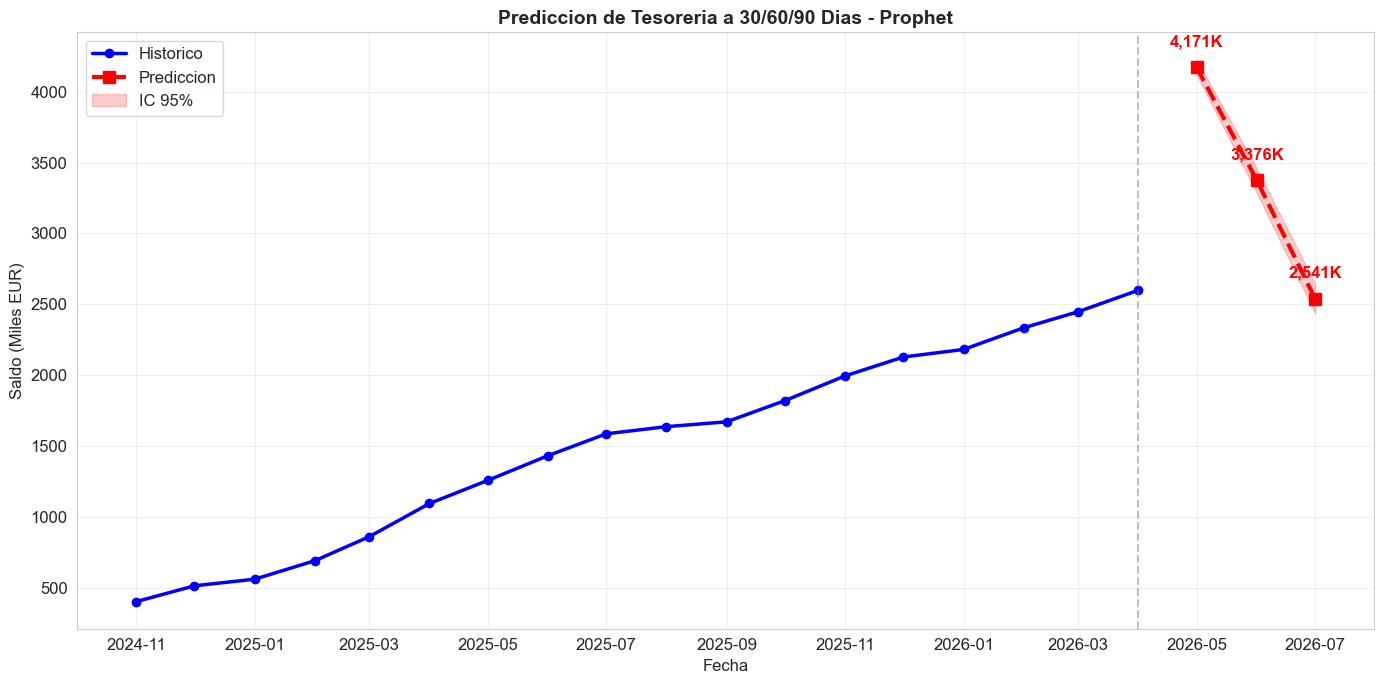

Grafico de prediccion futura generado.


In [16]:
# ============================================================
# 6d. VISUALIZAR PREDICCION FUTURA
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))

# Datos historicos (ultimos 18 meses para mejor visualizacion)
df_plot = df.tail(18)
ax.plot(df_plot['ds'], df_plot['saldo_cierre_mes']/1000,
        'b-o', linewidth=2.5, markersize=6, label='Historico')

# Prediccion futura
ax.plot(forecast_futuro['ds'], forecast_futuro['yhat']/1000,
        'r--s', linewidth=3, markersize=8, label='Prediccion')

# Intervalo de confianza
ax.fill_between(forecast_futuro['ds'],
                forecast_futuro['yhat_lower']/1000,
                forecast_futuro['yhat_upper']/1000,
                alpha=0.2, color='red', label='IC 95%')

# Linea divisoria
ax.axvline(x=df_plot['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.5)

# Etiquetas de valores en la prediccion
for _, row in forecast_futuro.iterrows():
    ax.annotate(f'{row["yhat"]/1000:,.0f}K',
                (row['ds'], row['yhat']/1000),
                textcoords='offset points', xytext=(0, 15),
                ha='center', fontweight='bold', color='red')

ax.set_title('Prediccion de Tesoreria a 30/60/90 Dias - Prophet', fontweight='bold', fontsize=14)
ax.set_ylabel('Saldo (Miles EUR)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Grafico de prediccion futura generado.')

---
## 7. Analisis de Riesgo y Alertas

Analizamos si la tesoreria podria caer por debajo de umbrales criticos.

In [17]:
# ============================================================
# 7. ANALISIS DE RIESGO
# ============================================================
print('=== ANALISIS DE RIESGO DE TESORERIA ===')
print('=' * 50)
print()

umbral_bajo = 200_000  # 200K EUR - umbral de alerta
umbral_critico = 100_000  # 100K EUR - umbral critico
saldo_actual = df['saldo_cierre_mes'].iloc[-1]

print(f'  Saldo actual:                 {saldo_actual:>12,.2f} EUR')
print(f'  Umbral de alerta:             {umbral_bajo:>12,.2f} EUR')
print(f'  Umbral critico:               {umbral_critico:>12,.2f} EUR')
print()

for _, row in forecast_futuro.iterrows():
    pred = row['yhat']
    lower = row['yhat_lower']
    fecha = row['ds'].strftime('%B %Y')
    
    riesgo_bajo = '⚠️' if lower < umbral_bajo else '✅'
    riesgo_critico = '🚨' if lower < umbral_critico else '✅'
    
    print(f'  {fecha}:')
    print(f'    Prediccion: {pred:>12,.2f} EUR | IC Inf: {lower:>12,.2f} EUR')
    print(f'    Alerta (200K): {riesgo_bajo}')
    print(f'    Critico (100K): {riesgo_critico}')
    print()

# Recomendacion
print('  RECOMENDACION:')
riesgo_min = forecast_futuro['yhat_lower'].min()
if riesgo_min < umbral_critico:
    print('  🚨 RIESGO CRITICO: La tesoreria podria caer por debajo de 100.000 EUR.')
    print('     Accion recomendada: Activar linea de credito urgentemente.')
elif riesgo_min < umbral_bajo:
    print('  ⚠️  RIESGO MODERADO: La tesoreria podria acercarse al umbral de 200.000 EUR.')
    print('     Accion recomendada: Revisar calendario de cobros y gastos.')
else:
    print('  ✅ RIESGO BAJO: La tesoreria se mantiene en niveles saludables.')

=== ANALISIS DE RIESGO DE TESORERIA ===

  Saldo actual:                 2,600,096.78 EUR
  Umbral de alerta:               200,000.00 EUR
  Umbral critico:                 100,000.00 EUR

  May 2026:
    Prediccion: 4,170,855.11 EUR | IC Inf: 4,118,851.88 EUR
    Alerta (200K): ✅
    Critico (100K): ✅

  June 2026:
    Prediccion: 3,375,884.21 EUR | IC Inf: 3,286,152.87 EUR
    Alerta (200K): ✅
    Critico (100K): ✅

  July 2026:
    Prediccion: 2,541,214.37 EUR | IC Inf: 2,438,064.08 EUR
    Alerta (200K): ✅
    Critico (100K): ✅

  RECOMENDACION:
  ✅ RIESGO BAJO: La tesoreria se mantiene en niveles saludables.


---
## 8. Guardar Modelo

Exportamos el modelo entrenado y las predicciones para usarlos en el dashboard de Power BI.

In [18]:
# ============================================================
# 8a. GUARDAR MODELO ENTRENADO
# ============================================================
modelo_path = os.path.join(MODEL_DIR, 'prophet_model.pkl')

with open(modelo_path, 'wb') as f:
    pickle.dump(modelo_final, f)

print(f'Modelo guardado en: {modelo_path}')
print(f'Tamano: {os.path.getsize(modelo_path)/1024:.1f} KB')

Modelo guardado en: ..\models\prophet_model.pkl
Tamano: 16.6 KB


In [19]:
# ============================================================
# 8b. EXPORTAR PREDICCIONES A CSV
# ============================================================
# Predicciones historicas (train+test) para comparativa
df_historico = df[['ds', 'saldo_cierre_mes', 'total_ingresos', 'total_gastos']].copy()
df_historico.columns = ['fecha', 'saldo_real', 'ingresos', 'gastos']
df_historico['tipo'] = 'historico'

# Predicciones futuras
df_prediccion = forecast_futuro[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
df_prediccion.columns = ['fecha', 'saldo_predicho', 'ic_inferior', 'ic_superior']
df_prediccion['tipo'] = 'prediccion'

# Combinar
df_export = pd.merge(
    df_historico,
    df_prediccion,
    on=['fecha', 'tipo'],
    how='outer'
)

# Si no hay merge directo, construir manual
# Historico
df_historico['saldo_predicho'] = None
df_historico['ic_inferior'] = None
df_historico['ic_superior'] = None

# Prediccion
df_prediccion['saldo_real'] = None
df_prediccion['ingresos'] = None
df_prediccion['gastos'] = None

df_final = pd.concat([df_historico, df_prediccion], ignore_index=True)
df_final = df_final.sort_values('fecha').reset_index(drop=True)
df_final['fecha'] = df_final['fecha'].dt.strftime('%Y-%m-%d')

pred_path = os.path.join(PROCESSED_DIR, 'predicciones.csv')
df_final.to_csv(pred_path, index=False, encoding='utf-8-sig')

print(f'Predicciones exportadas a: {pred_path}')
print(f'Registros: {len(df_final)}')
print(f'Historicos: {len(df_historico)} | Predicciones: {len(df_prediccion)}')
print()
print('Columnas disponibles para Power BI:')
for col in df_final.columns:
    print(f'  - {col}')

Predicciones exportadas a: ..\data\processed\predicciones.csv
Registros: 43
Historicos: 40 | Predicciones: 3

Columnas disponibles para Power BI:
  - fecha
  - saldo_real
  - ingresos
  - gastos
  - tipo
  - saldo_predicho
  - ic_inferior
  - ic_superior


In [20]:
# ============================================================
# 8c. RESUMEN FINAL
# ============================================================
print('=' * 60)
print('   RESUMEN FINAL - MODELO DE FORECASTING')
print('=' * 60)
print()
print(f'  Target:             saldo_cierre_mes (posicion de tesoreria)')
print(f'  Modelo:             Prophet con regresores externos')
print(f'  Regresores:         IPC, Euribor, Estacionalidad, Ingresos, Gastos')
print(f'  Datos entrenamiento: {len(df_train)} meses')
print(f'  Datos test:          {len(df_test)} meses')
print(f'  Horizonte prediccion: 90 dias (3 meses)')
print()
print(f'  METRICAS (test):')
print(f'    MAE:  {mae:>10,.2f} EUR')
print(f'    RMSE: {rmse:>10,.2f} EUR')
print(f'    MAPE: {mape:>9.2f}%')
print(f'    R²:   {r2:>9.4f}')
print()
print(f'  ARCHIVOS GENERADOS:')
print(f'    - notebooks/02_modelo_forecasting.ipynb')
print(f'    - models/prophet_model.pkl')
print(f'    - data/processed/predicciones.csv')
print(f'    - data/processed/be_expand_consolidado.csv')
print()
print('  OK - Modelo de forecasting completado.')

   RESUMEN FINAL - MODELO DE FORECASTING

  Target:             saldo_cierre_mes (posicion de tesoreria)
  Modelo:             Prophet con regresores externos
  Regresores:         IPC, Euribor, Estacionalidad, Ingresos, Gastos
  Datos entrenamiento: 32 meses
  Datos test:          8 meses
  Horizonte prediccion: 90 dias (3 meses)

  METRICAS (test):
    MAE:  471,000.57 EUR
    RMSE: 561,066.05 EUR
    MAPE:     21.46%
    R²:     -2.6726

  ARCHIVOS GENERADOS:
    - notebooks/02_modelo_forecasting.ipynb
    - models/prophet_model.pkl
    - data/processed/predicciones.csv
    - data/processed/be_expand_consolidado.csv

  OK - Modelo de forecasting completado.
